## 2. Khảo sát bộ dữ liệu sinh viên (`data/sinh_vien.csv`)
Tệp dữ liệu gồm 120 dòng và 3 cột:
- `gio_on`: Số giờ ôn tập trước kỳ thi (từ 0.0 đến 29.5 giờ).
- `diem_giua_ky`: Điểm bài kiểm tra giữa kỳ (từ 0.0 đến 10.0 điểm).
- `qua_mon`: Biến mục tiêu cần đoán (0: Rớt môn, 1: Qua môn).


In [1]:
import pandas as pd

# Đọc bộ dữ liệu sinh viên
df = pd.read_csv("data/sinh_vien.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()
print("Nam dong dau tien:")
print(df.head())
print()
print("So sinh vien theo ket qua:")
print(df["qua_mon"].value_counts())
print()
print("Ty le qua mon:", round(df["qua_mon"].mean(), 4))
print()
print("So gio on trung binh theo nhom:")
print(df.groupby("qua_mon")["gio_on"].mean().round(2))


Kich thuoc bang (so dong, so cot): (120, 3)

Nam dong dau tien:
   gio_on  diem_giua_ky  qua_mon
0     5.5           3.0        0
1    19.0           6.0        1
2    14.0           7.7        0
3    11.0           3.1        0
4    10.5           5.8        1

So sinh vien theo ket qua:
qua_mon
1    71
0    49
Name: count, dtype: int64

Ty le qua mon: 0.5917

So gio on trung binh theo nhom:
qua_mon
0     8.29
1    19.89
Name: gio_on, dtype: float64


### Nhận xét quan trọng:
1. **Phân bố nhãn:** 71 bạn qua môn và 49 bạn rớt môn. Tỷ lệ qua môn đạt 59.17% (hai lớp cân bằng tốt).
2. **Đặc trưng `gio_on`:** Nhóm rớt ôn trung bình **8.29 giờ**, nhóm qua ôn trung bình **19.89 giờ** (chênh lệch hơn 2 lần). Đây là cơ sở vững chắc cho thấy số giờ ôn tập có khả năng phân loại rất mạnh mẽ.


## 2.4. Vì sao không dùng lại đường thẳng của Bài 1?
1. **Giá trị dự đoán vượt ngoài $[0, 1]$:** Đường thẳng nhận giá trị từ $-0.103$ tới $1.250$. Giá trị xác suất bằng $125\%$ hay âm là hoàn toàn vô nghĩa.
2. **Nhạy cảm với điểm ngoại lai (Outliers):** MSE phạt bình phương sai số nên các điểm xa sẽ kéo lệch đường thẳng và làm sai lệch ranh giới quyết định.
3. **Giả định phân phối:** Linear Regression giả định nhiễu tuân theo phân phối Gauss (Gaussian), trong khi nhãn 0/1 tuân theo phân phối Bernoulli.


c:\Users\nthie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


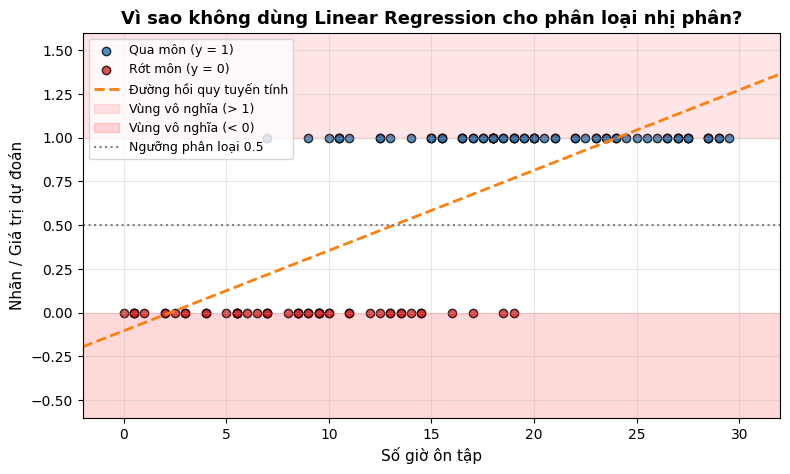

In [2]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Thử khớp Linear Regression trên nhãn 0 và 1
lr = LinearRegression()
lr.fit(df[["gio_on"]], df["qua_mon"])

x_plot = np.linspace(-2, 32, 200).reshape(-1, 1)
y_plot = lr.predict(x_plot)

plt.figure(figsize=(9, 5))
plt.scatter(df[df["qua_mon"]==1]["gio_on"], df[df["qua_mon"]==1]["qua_mon"], 
            color="#1f77b4", label="Qua môn (y = 1)", alpha=0.8, edgecolors="k")
plt.scatter(df[df["qua_mon"]==0]["gio_on"], df[df["qua_mon"]==0]["qua_mon"], 
            color="#d62728", label="Rớt môn (y = 0)", alpha=0.8, edgecolors="k")
plt.plot(x_plot, y_plot, color="#ff7f0e", linestyle="--", linewidth=2, label="Đường hồi quy tuyến tính")

# Vùng vô nghĩa
plt.axhspan(1, 1.6, color="red", alpha=0.1, label="Vùng vô nghĩa (> 1)")
plt.axhspan(-0.6, 0, color="red", alpha=0.15, label="Vùng vô nghĩa (< 0)")
plt.axhline(0.5, color="gray", linestyle=":", label="Ngưỡng phân loại 0.5")

plt.title("Vì sao không dùng Linear Regression cho phân loại nhị phân?", fontsize=13, fontweight="bold")
plt.xlabel("Số giờ ôn tập", fontsize=11)
plt.ylabel("Nhãn / Giá trị dự đoán", fontsize=11)
plt.ylim(-0.6, 1.6)
plt.xlim(-2, 32)
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()


---

## 3. Hàm Sigmoid
Để ép đầu ra tuyến tính $z = w^T x + b$ về khoảng xác suất $(0, 1)$, ta sử dụng hàm **Sigmoid (hàm logistic)**:
$$\sigma(z) = 
rac{1}{1 + e^{-z}}$$

**Ba tính chất cốt lõi:**
1. **Tiến tới 0 và 1:** Khi $z 	o -\infty$, $e^{-z} 	o +\infty \implies \sigma(z) 	o 0$. Khi $z 	o +\infty$, $e^{-z} 	o 0 \implies \sigma(z) 	o 1$.
2. **Đi qua điểm 0.5 tại gốc:** Khi $z = 0$, $e^0 = 1 \implies \sigma(0) = 
rac{1}{2} = 0.5$.
3. **Tính chất đối xứng:** $\sigma(-z) = 1 - \sigma(z)$, đảm bảo tổng xác suất hai lớp $P(y=0) + P(y=1) = 1$.


In [3]:
import numpy as np

def sigmoid(z):
    '''Ep mot so thuc bat ky ve khoang tu 0 toi 1.'''
    return 1 / (1 + np.exp(-z))

print("Bang gia tri cua ham sigmoid")
print("  z    sigmoid(z)")
for z in [-6, -4, -2, -1, 0, 1, 2, 4, 6]:
    print(f"{z:3d}    {sigmoid(z):.4f}")
print()

# Hai tính chất cần tự kiểm chứng
print("Kiem tra sigmoid(-z) = 1 - sigmoid(z):")
for z in [1.0, 2.5, 3.7]:
    trai = sigmoid(-z)
    phai = 1 - sigmoid(z)
    print(f"  z = {z}: {trai:.6f} va {phai:.6f}")
print()

# Thử với một mô hình giả định w = 0.4 và b = -5
w, b = 0.4, -5.0
print(f"Mo hinh gia dinh: w = {w}, b = {b}")
print("  So gio on  z = w*x + b  Xac suat qua mon")
for gio in [5, 10, 12.5, 15, 20, 25]:
    z = w * gio + b
    print(f"     {gio:5.1f}       {z:6.2f}         {sigmoid(z):.4f}")


Bang gia tri cua ham sigmoid
  z    sigmoid(z)
 -6    0.0025
 -4    0.0180
 -2    0.1192
 -1    0.2689
  0    0.5000
  1    0.7311
  2    0.8808
  4    0.9820
  6    0.9975

Kiem tra sigmoid(-z) = 1 - sigmoid(z):
  z = 1.0: 0.268941 va 0.268941
  z = 2.5: 0.075858 va 0.075858
  z = 3.7: 0.024127 va 0.024127

Mo hinh gia dinh: w = 0.4, b = -5.0
  So gio on  z = w*x + b  Xac suat qua mon
       5.0        -3.00         0.0474
      10.0        -1.00         0.2689
      12.5         0.00         0.5000
      15.0         1.00         0.7311
      20.0         3.00         0.9526
      25.0         5.00         0.9933


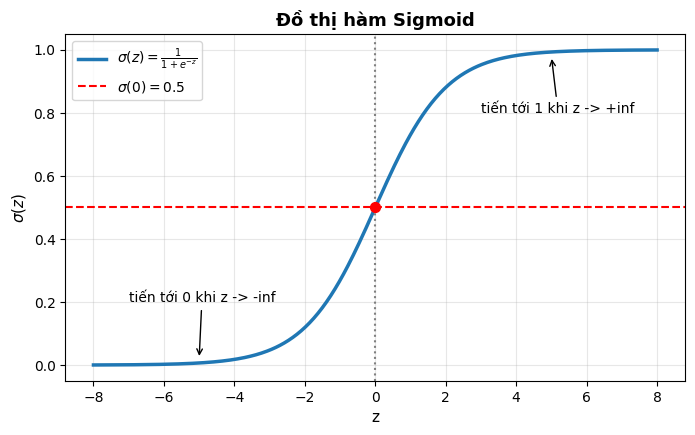

In [4]:
z_vals = np.linspace(-8, 8, 400)
sig_vals = sigmoid(z_vals)

plt.figure(figsize=(8, 4.5))
plt.plot(z_vals, sig_vals, color="#1f77b4", linewidth=2.5, label=r"$\sigma(z) = \frac{1}{1 + e^{-z}}$")
plt.axhline(0.5, color="red", linestyle="--", label=r"$\sigma(0) = 0.5$")
plt.axvline(0, color="gray", linestyle=":")
plt.scatter([0], [0.5], color="red", s=50, zorder=5)

plt.annotate("tiến tới 1 khi z -> +inf", xy=(5, 0.98), xytext=(3, 0.8),
             arrowprops=dict(arrowstyle="->", color="black"), fontsize=10)
plt.annotate("tiến tới 0 khi z -> -inf", xy=(-5, 0.02), xytext=(-7, 0.2),
             arrowprops=dict(arrowstyle="->", color="black"), fontsize=10)

plt.title("Đồ thị hàm Sigmoid", fontsize=13, fontweight="bold")
plt.xlabel("z", fontsize=11); plt.ylabel(r"$\sigma(z)$", fontsize=11)
plt.grid(True, alpha=0.3); plt.legend(loc="upper left")
plt.show()


---

## 4. Khớp mô hình bằng Scikit-Learn
Ta sử dụng lớp `LogisticRegression` từ thư viện `sklearn.linear_model`.  
| Bước | Hồi quy tuyến tính (Bài 1) | Hồi quy Logistic (Bài 2) |
|---|---|---|
| 1. Khởi tạo | `LinearRegression()` | `LogisticRegression()` |
| 2. Huấn luyện | `.fit(X, y)` | `.fit(X, y)` |
| 3. Dự đoán | `.predict(X_moi)` | `.predict(X_moi)` hoặc `.predict_proba(X_moi)` |

> **Lưu ý định dạng dữ liệu:**  
> - `X` phải là mảng 2 chiều (`df[["gio_on"]]` - hai cặp ngoặc vuông).  
> - `y` là chuỗi 1 chiều (`df["qua_mon"]` - một cặp ngoặc vuông).


In [5]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()
print(f"So gio on ung voi xac suat 0.5: {-b / w:.2f} gio")
print()

can_moi = pd.DataFrame({"gio_on": [5.0, 10.0, 13.0, 20.0, 28.0]})
xac_suat = mo_hinh.predict_proba(can_moi)[:, 1]
nhan = mo_hinh.predict(can_moi)

print("Du doan cho nam ban moi:")
print("  So gio on  Xac suat qua  Nhan mo hinh dua ra")
for gio, p, n in zip(can_moi["gio_on"], xac_suat, nhan):
    print(f"     {gio:5.1f}        {p:.4f}           {n}")


He so goc w = 0.392819
He so chan b = -5.064890

So gio on ung voi xac suat 0.5: 12.89 gio

Du doan cho nam ban moi:
  So gio on  Xac suat qua  Nhan mo hinh dua ra
       5.0        0.0431           0
      10.0        0.2429           0
      13.0        0.5104           1
      20.0        0.9422           1
      28.0        0.9974           1


c:\Users\nthie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


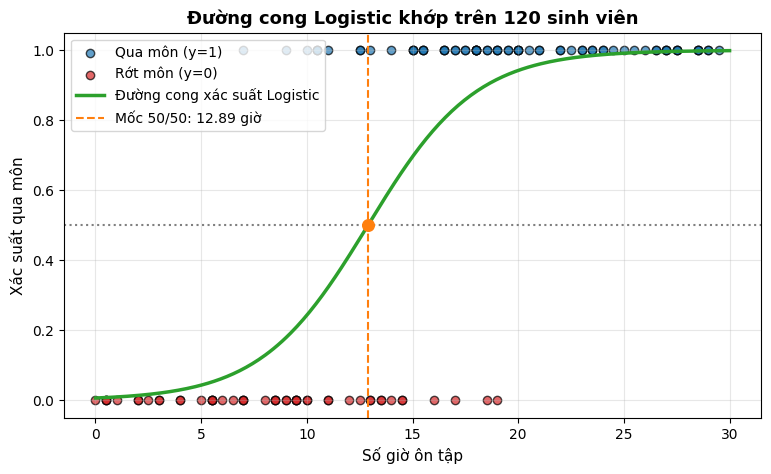

In [6]:
x_dense = np.linspace(0, 30, 300).reshape(-1, 1)
y_dense_prob = mo_hinh.predict_proba(x_dense)[:, 1]

plt.figure(figsize=(9, 5))
plt.scatter(df[df["qua_mon"]==1]["gio_on"], df[df["qua_mon"]==1]["qua_mon"], 
            color="#1f77b4", label="Qua môn (y=1)", alpha=0.7, edgecolors="k")
plt.scatter(df[df["qua_mon"]==0]["gio_on"], df[df["qua_mon"]==0]["qua_mon"], 
            color="#d62728", label="Rớt môn (y=0)", alpha=0.7, edgecolors="k")
plt.plot(x_dense, y_dense_prob, color="#2ca02c", linewidth=2.5, label="Đường cong xác suất Logistic")

# Đường ngưỡng 12.89 giờ
plt.axvline(-b/w, color="#ff7f0e", linestyle="--", linewidth=1.5, label=f"Mốc 50/50: {-b/w:.2f} giờ")
plt.axhline(0.5, color="gray", linestyle=":")
plt.scatter([-b/w], [0.5], color="#ff7f0e", s=70, zorder=5)

plt.title("Đường cong Logistic khớp trên 120 sinh viên", fontsize=13, fontweight="bold")
plt.xlabel("Số giờ ôn tập", fontsize=11)
plt.ylabel("Xác suất qua môn", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.show()


---

## 5. Chấm điểm mô hình (Model Evaluation)
### 5.1. Ma trận nhầm lẫn (Confusion Matrix)
Với bài toán phân loại nhị phân (0 và 1), các dự đoán được phân thành 4 ô:
- **TP (True Positive):** Đoán qua môn, thực tế qua môn (Đoán đúng).
- **TN (True Negative):** Đoán rớt môn, thực tế rớt môn (Đoán đúng).
- **FP (False Positive):** Đoán qua môn, thực tế rớt môn (Đoán sai - Báo động giả).
- **FN (False Negative):** Đoán rớt môn, thực tế qua môn (Đoán sai - Bỏ sót).

### 5.2. Bốn thước đo định lượng
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} = \frac{\text{Số ca đoán đúng}}{\text{Tổng số ca}}$$
$$\text{Precision} = \frac{TP}{TP + FP} = \frac{\text{Đúng trong những ca đoán là 1}}{\text{Tổng số ca mô hình đoán 1}}$$
$$\text{Recall} = \frac{TP}{TP + FN} = \frac{\text{Bắt được bao nhiêu ca thực sự là 1}}{\text{Tổng số ca thực tế là 1}}$$
$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             f1_score, precision_score, recall_score)

# Chia tập học và tập kiểm tra (stratify=y giữ đúng tỷ lệ 59% qua môn ở 2 tập)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

print("So sinh vien de hoc      :", len(X_train))
print("So sinh vien de kiem tra :", len(X_test))
print()

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

# Lấy 4 giá trị ma trận nhầm lẫn
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Ma tran nham lan:")
print(f"  TN = {tn:2d}  doan rot, that su rot")
print(f"  FP = {fp:2d}  doan qua, that ra rot")
print(f"  FN = {fn:2d}  doan rot, that ra qua")
print(f"  TP = {tp:2d}  doan qua, that su qua")
print()

print(f"Accuracy  = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision = {precision_score(y_test, y_pred):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred):.4f}")
print(f"F1        = {f1_score(y_test, y_pred):.4f}")
print()

# Tự tính lại bằng tay đối chiếu
print("Tu tinh lai bang cong thuc:")
n = len(y_test)
print(f"  Accuracy  = ({tp} + {tn}) / {n} = {(tp + tn) / n:.4f}")
print(f"  Precision = {tp} / ({tp} + {fp}) = {tp / (tp + fp):.4f}")
print(f"  Recall    = {tp} / ({tp} + {fn}) = {tp / (tp + fn):.4f}")


So sinh vien de hoc      : 90
So sinh vien de kiem tra : 30

Ma tran nham lan:
  TN =  9  doan rot, that su rot
  FP =  3  doan qua, that ra rot
  FN =  1  doan rot, that ra qua
  TP = 17  doan qua, that su qua

Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1        = 0.8947

Tu tinh lai bang cong thuc:
  Accuracy  = (17 + 9) / 30 = 0.8667
  Precision = 17 / (17 + 3) = 0.8500
  Recall    = 17 / (17 + 1) = 0.9444


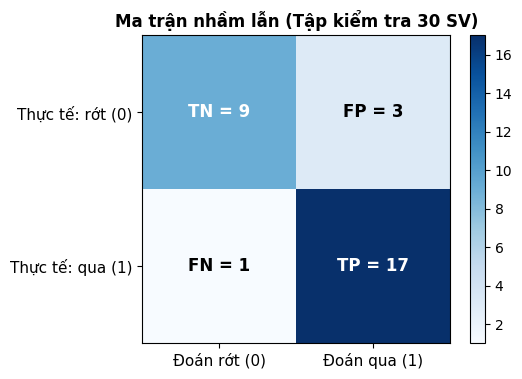

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(cm, cmap="Blues")

# Hiển thị số lượng và nhãn từng ô
labels = [["TN = " + str(tn), "FP = " + str(fp)],
          ["FN = " + str(fn), "TP = " + str(tp)]]

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max()/2 else "black"
        ax.text(j, i, labels[i][j], ha="center", va="center", color=color, fontsize=12, fontweight="bold")

ax.set_xticks([0, 1]); ax.set_xticklabels(["Đoán rớt (0)", "Đoán qua (1)"], fontsize=11)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Thực tế: rớt (0)", "Thực tế: qua (1)"], fontsize=11)
plt.title("Ma trận nhầm lẫn (Tập kiểm tra 30 SV)", fontsize=12, fontweight="bold")
plt.colorbar(im)
plt.show()


---

## 6. Ngưỡng quyết định (Decision Threshold)
Mặc định mô hình gán nhãn 1 nếu xác suất $\hat{p} \ge 0.5$. Tuy nhiên, ta hoàn toàn có thể tự chọn ngưỡng $t \in [0, 1]$:
$$\hat{c} = 1 	ext{ nếu } \hat{p} \ge t, \quad \hat{c} = 0 	ext{ nếu } \hat{p} < t$$

**Quy luật đánh đổi Precision - Recall:**
- **Hạ ngưỡng ($t$ giảm):** Mô hình dễ dãi hơn, gắn nhãn 1 cho nhiều người hơn $\implies$ **Recall tăng**, nhưng **Precision giảm**.
- **Nâng ngưỡng ($t$ tăng):** Mô hình khắt khe hơn, chỉ gán nhãn 1 khi rất chắc chắn $\implies$ **Precision tăng**, nhưng **Recall giảm**.


In [9]:
p_test = mo_hinh.predict_proba(X_test)[:, 1]

print("Nguong  So ban bi doan la qua  Precision  Recall")
for nguong in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred_t = (p_test >= nguong).astype(int)
    pre = precision_score(y_test, y_pred_t, zero_division=1)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    print(f"  {nguong:.1f}           {y_pred_t.sum():3d}          {pre:.4f}    {rec:.4f}")
print()
print("Doc bang tren tu duoi len:")
print("  Nguong cang cao thi mo hinh cang kho tinh,")
print("  precision tang nhung recall giam. Nguong thap thi nguoc lai.")


Nguong  So ban bi doan la qua  Precision  Recall
  0.2            24          0.7500    1.0000
  0.3            20          0.8500    0.9444
  0.4            20          0.8500    0.9444
  0.5            20          0.8500    0.9444
  0.6            16          1.0000    0.8889
  0.7            15          1.0000    0.8333
  0.8            13          1.0000    0.7222

Doc bang tren tu duoi len:
  Nguong cang cao thi mo hinh cang kho tinh,
  precision tang nhung recall giam. Nguong thap thi nguoc lai.


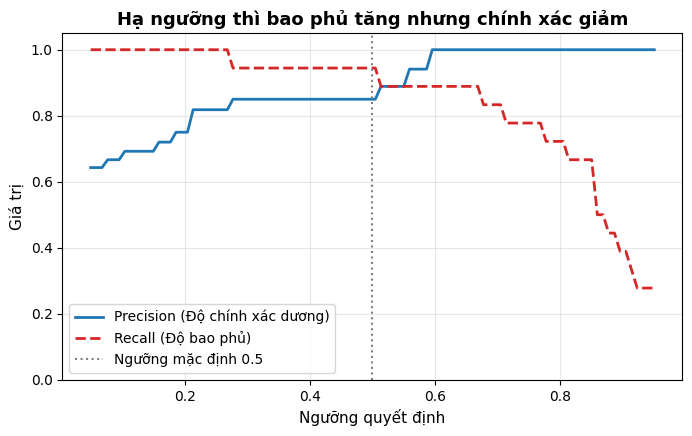

In [10]:
t_range = np.linspace(0.05, 0.95, 100)
pre_curve, rec_curve = [], []

for t in t_range:
    y_pred_curve = (p_test >= t).astype(int)
    pre_curve.append(precision_score(y_test, y_pred_curve, zero_division=1))
    rec_curve.append(recall_score(y_test, y_pred_curve, zero_division=0))

plt.figure(figsize=(8, 4.5))
plt.plot(t_range, pre_curve, color="#1f77b4", linewidth=2, label="Precision (Độ chính xác dương)")
plt.plot(t_range, rec_curve, color="#d62728", linestyle="--", linewidth=2, label="Recall (Độ bao phủ)")
plt.axvline(0.5, color="gray", linestyle=":", label="Ngưỡng mặc định 0.5")

plt.title("Hạ ngưỡng thì bao phủ tăng nhưng chính xác giảm", fontsize=13, fontweight="bold")
plt.xlabel("Ngưỡng quyết định", fontsize=11)
plt.ylabel("Giá trị", fontsize=11)
plt.ylim(0.0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower left", fontsize=10)
plt.show()


---

## 7. Thêm biến đầu vào thứ hai (`diem_giua_ky`)
Kết quả cuối môn chịu ảnh hưởng của cả số giờ ôn và điểm giữa kỳ:
$$\hat{y} = \sigma(w_1 x_1 + w_2 x_2 + b)$$
với $x_1$ là số giờ ôn tập và $x_2$ là điểm giữa kỳ.  
Chỉ cần bổ sung tên cột vào danh sách: `X = df[["gio_on", "diem_giua_ky"]]`.


In [11]:
for ten, cot in [("Mot bien", ["gio_on"]), 
                 ("Hai bien", ["gio_on", "diem_giua_ky"])]:
    X_sub = df[cot]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sub, y, test_size=0.25, random_state=17, stratify=y
    )
    m = LogisticRegression().fit(X_tr, y_tr)
    acc = accuracy_score(y_te, m.predict(X_te))
    print(f"{ten}: accuracy tren tap kiem tra = {acc:.4f}")
print()

# Xem chi tiết hệ số mô hình 2 biến
X_2b = df[["gio_on", "diem_giua_ky"]]
X_tr, X_te, y_tr, y_te = train_test_split(
    X_2b, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh_2b = LogisticRegression().fit(X_tr, y_tr)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X_2b.columns, mo_hinh_2b.coef_[0]):
    print(f"  {ten_cot:14s} {he_so:+.4f}")
print(f"  {'he so chan':14s} {mo_hinh_2b.intercept_[0]:+.4f}")
print()
print("Ca hai he so deu duong, nghia la on nhieu hon va")
print("diem giua ky cao hon deu lam tang xac suat qua mon.")


Mot bien: accuracy tren tap kiem tra = 0.8667
Hai bien: accuracy tren tap kiem tra = 0.9000

He so cua tung bien:
  gio_on         +0.3035
  diem_giua_ky   +0.5885
  he so chan     -6.9811

Ca hai he so deu duong, nghia la on nhieu hon va
diem giua ky cao hon deu lam tang xac suat qua mon.


c:\Users\nthie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


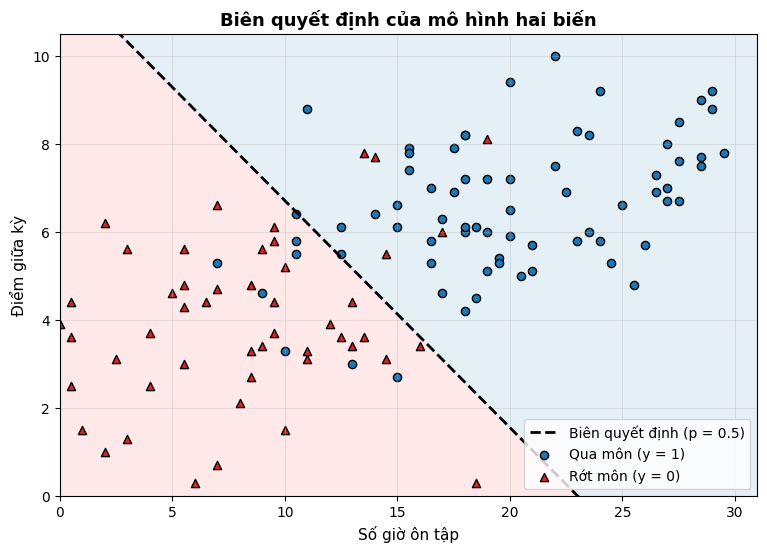

In [12]:
# Vẽ biên quyết định 2D
X_2b = df[["gio_on", "diem_giua_ky"]]
X_tr, X_te, y_tr, y_te = train_test_split(
    X_2b, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh_2b = LogisticRegression().fit(X_tr, y_tr)
w1, w2 = mo_hinh_2b.coef_[0]
b_2b = mo_hinh_2b.intercept_[0]

# Ranh giới quyết định khi w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b) / w2
x1_vals = np.linspace(0, 30, 200)
x2_boundary = -(w1 * x1_vals + b_2b) / w2

plt.figure(figsize=(9, 6))
# Vùng dự đoán qua/rớt
x1_grid, x2_grid = np.meshgrid(np.linspace(0, 31, 200), np.linspace(0, 11, 200))
grid_points = np.c_[x1_grid.ravel(), x2_grid.ravel()]
probs_grid = mo_hinh_2b.predict_proba(grid_points)[:, 1].reshape(x1_grid.shape)

plt.contourf(x1_grid, x2_grid, probs_grid, levels=[0, 0.5, 1], colors=["#ffd9d9", "#d4e6f1"], alpha=0.6)
plt.plot(x1_vals, x2_boundary, color="black", linestyle="--", linewidth=2, label="Biên quyết định (p = 0.5)")

# Vẽ các điểm dữ liệu thật
plt.scatter(df[df["qua_mon"]==1]["gio_on"], df[df["qua_mon"]==1]["diem_giua_ky"], 
            color="#1f77b4", marker="o", label="Qua môn (y = 1)", edgecolors="k", s=35)
plt.scatter(df[df["qua_mon"]==0]["gio_on"], df[df["qua_mon"]==0]["diem_giua_ky"], 
            color="#d62728", marker="^", label="Rớt môn (y = 0)", edgecolors="k", s=35)

plt.title("Biên quyết định của mô hình hai biến", fontsize=13, fontweight="bold")
plt.xlabel("Số giờ ôn tập", fontsize=11)
plt.ylabel("Điểm giữa kỳ", fontsize=11)
plt.xlim(0, 31); plt.ylim(0, 10.5)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")
plt.show()


### Nhận xét về Biên quyết định (Decision Boundary):
1. **Biên quyết định luôn là đường thẳng (hoặc siêu phẳng):** Tập hợp các điểm thỏa mãn $w_1 x_1 + w_2 x_2 + b = 0$ là một đường thẳng phân cách không gian đặc trưng thành hai nửa: nửa dự đoán qua môn (vùng xanh) và nửa dự đoán rớt môn (vùng hồng).
2. **Không so sánh độ lớn trực tiếp của $w_1$ và $w_2$:** Dù $w_2 = 0.5885$ lớn gần gấp đôi $w_1 = 0.3035$, ta không thể kết luận `diem_giua_ky` quan trọng gấp đôi `gio_on`, vì hai đặc trưng này có thang đo khác nhau (`gio_on` từ 0 đến 29.5, `diem_giua_ky` từ 0 đến 10). Muốn so sánh tầm quan trọng, cần chuẩn hóa thang đo bằng `StandardScaler`.

---
## 9. Tổng kết các kết quả chính
- Mô hình 1 biến: $\hat{p} = \sigma(0.3928 \cdot x - 5.0649)$, mốc $50/50$ tại $12.89$ giờ ôn.
- Ma trận nhầm lẫn trên 30 sinh viên kiểm tra: $TP=17, TN=9, FP=3, FN=1$.
- Các chỉ số: $\text{Accuracy} = 0.8667$, $\text{Precision} = 0.8500$, $\text{Recall} = 0.9444$, $F_1 = 0.8947$.
- Mô hình 2 biến: $\text{Accuracy}$ tăng lên $0.9000$ với $w_1 = +0.3035, w_2 = +0.5885, b = -6.9811$.
